In [2]:
!pip install PyWavelets

import numpy as np
import pandas as pd
import pywt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

In [3]:
import numpy as np
import pandas as pd
import pywt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

class HybridAdaptiveSensorCalibration:
    def __init__(self, window_size=24, error_scale=2.0, min_trust_score=0.2,
                 sensor_positions=None, D=5.0, use_spatial=True):
        self.window_size = window_size
        self.error_scale = error_scale
        self.min_trust_score = min_trust_score
        self.sensor_positions = sensor_positions if sensor_positions else {}
        self.D = D
        self.use_spatial = use_spatial
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='mean')
        self.trust_scores = {}
        self.offsets_ = {}
        self.scales_ = {}

    def fit_offset_scale(self, data, sensors, ref='Ref'):
        for sensor in sensors:
            valid_mask = ~data[[sensor, ref]].isna().any(axis=1)
            x = data.loc[valid_mask, sensor].values
            y = data.loc[valid_mask, ref].values
            if len(x) < 2:
                self.offsets_[sensor] = 0.0
                self.scales_[sensor] = 1.0
                continue
            slope, intercept, _, _, _ = stats.linregress(x, y)
            b_i = slope if not np.isclose(slope, 0) else 1e-6
            a_i = -intercept / b_i
            self.offsets_[sensor] = a_i
            self.scales_[sensor] = b_i

    def apply_offset_scale(self, data, sensors):
        df = data.copy()
        for sensor in sensors:
            a_i = self.offsets_.get(sensor, 0.0)
            b_i = self.scales_.get(sensor, 1.0)
            df[sensor] = b_i * (df[sensor] - a_i)
        return df

    def compute_trust_score(self, data, sensor, ref='Ref'):
        errors = np.abs(data[sensor] - data[ref])
        accuracy_score = np.mean(np.exp(-errors / self.error_scale))
        rolling_std = data[sensor].rolling(window=self.window_size, min_periods=1).std()
        denom = data[sensor].mean() if data[sensor].mean() != 0 else 1e-6
        stability_score = np.mean(np.exp(-rolling_std / denom))
        try:
            responsiveness_score = abs(stats.pearsonr(
                data[sensor].diff().fillna(0), data[ref].diff().fillna(0)
            )[0])
        except Exception:
            responsiveness_score = 0.0
        other_cols = [c for c in data.columns if c not in [sensor, 'Date']]
        consensus_series = data[other_cols].mean(axis=1)
        try:
            corr_val = stats.pearsonr(data[sensor], consensus_series)[0]
        except Exception:
            corr_val = 0.0
        consensus_score = np.exp(-abs(corr_val - 1))
        trust_raw = (accuracy_score + stability_score +
                     responsiveness_score + consensus_score) / 4.0
        return max(trust_raw, self.min_trust_score)

    def _extract_wavelet_features(self, series, wavelet='db1', level=3):
        coeffs = pywt.wavedec(series, wavelet, level=level)
        feats = {}
        for i, cff in enumerate(coeffs):
            feats[f'wave_mean_{i}'] = np.mean(np.abs(cff))
            feats[f'wave_std_{i}']  = np.std(cff)
            feats[f'wave_max_{i}']  = np.max(np.abs(cff))
        return feats

    def _build_spatial_consensus(self, data, sensor, sensors):
        if not self.use_spatial or sensor not in self.sensor_positions:
            return data[[s for s in sensors if s != sensor]].mean(axis=1)
        (xi, yi) = self.sensor_positions[sensor]
        w_sum = 0.0
        weighted_val = pd.Series(0.0, index=data.index)
        for s_other in sensors:
            if s_other == sensor:
                continue
            if s_other not in self.sensor_positions:
                w = 1.0
            else:
                (xj, yj) = self.sensor_positions[s_other]
                dist = np.sqrt((xi - xj)**2 + (yi - yj)**2)
                w = np.exp(-dist / self.D)
            weighted_val += w * data[s_other]
            w_sum += w
        if w_sum == 0:
            return data[[s for s in sensors if s != sensor]].mean(axis=1)
        return weighted_val / w_sum

    def build_advanced_features(self, data, sensor, sensors, trust_scores=None, ref='Ref'):
        feats = {}
        wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
        feats.update(wavelet_feats)
        feats['roll_mean'] = data[sensor].rolling(window=self.window_size, min_periods=1).mean()
        feats['roll_std']  = data[sensor].rolling(window=self.window_size, min_periods=1).std()
        if trust_scores is not None:
            feats['spatial_consensus'] = self._build_spatial_consensus(data, sensor, sensors)
        else:
            feats['spatial_consensus'] = data[[s for s in sensors if s != sensor]].mean(axis=1)
        feats['sensor_val'] = data[sensor]
        feats['hour'] = pd.to_datetime(data['Date']).dt.hour.fillna(0)
        for other in sensors:
            if other != sensor:
                corrs = data[sensor].rolling(self.window_size).corr(data[other]).fillna(0)
                feats[f'corr_{other}'] = corrs
        feat_df = pd.DataFrame(feats, index=data.index).replace([np.inf, -np.inf], np.nan)
        return feat_df

    # --- MÉTODO UNIFICADO Y CORREGIDO ---
    def build_adaptive_model(self, trust_score, model_type='gb'):
        """Método unificado que permite elegir el modelo"""
        if model_type == 'gb':
            return GradientBoostingRegressor(
                n_estimators=int(100 + (1 - trust_score)*100),
                learning_rate=max(0.01, trust_score*0.1),
                max_depth=int(2 + (1 - trust_score)*2),
                random_state=42
            )
        elif model_type == 'rf':
            return RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
        elif model_type == 'xgb':
            return XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
        elif model_type == 'lr':
            return LinearRegression()
        return GradientBoostingRegressor()

    def fit_transform(self, data, sensors, ref='Ref', model_type='gb'):
        df = data.copy()
        self.fit_offset_scale(df, sensors, ref)
        df_corrected = self.apply_offset_scale(df, sensors)
        calibrated = {}
        for s in sensors:
            trust = self.compute_trust_score(df_corrected, s, ref)
            self.trust_scores[s] = trust
            feats_df = self.build_advanced_features(df_corrected, s, sensors, self.trust_scores, ref)
            arr_imp = self.imputer.fit_transform(feats_df)
            arr_scl = self.scaler.fit_transform(arr_imp)

            # Aquí pasamos el tipo de modelo dinámicamente
            model = self.build_adaptive_model(trust, model_type=model_type)

            model.fit(arr_scl, df_corrected[ref])
            preds = model.predict(arr_scl)
            final_vals = min(0.8, trust)*df_corrected[s] + (1 - min(0.8, trust))*preds
            calibrated[s] = final_vals
        return pd.DataFrame(calibrated, index=df_corrected.index), self.trust_scores

In [4]:
import pandas as pd

# Cargamos el archivo que preparamos en el otro cuaderno
df = pd.read_csv('datos_preparados_smartgrids.csv')

# Aseguramos que la columna Date sea interpretada como tiempo por Python
df['Date'] = pd.to_datetime(df['Date'])

# Verificamos que todo se vea bien
df.head()

,Date,Sensor_202,Sensor_335,Sensor_390,Sensor_391,Sensor_409,Sensor_422,Ref,temperature,humidity
0,2026-06-26 09:00:00,5.290000,5.114242,4.978485,5.025000,4.920625,5.099091,6.94995,24.640177,81.483414
1,2026-06-26 10:00:00,4.283898,4.604915,4.428983,4.523051,4.364746,4.503729,9.28072,26.174825,73.011704
2,2026-06-26 11:00:00,3.655833,3.983333,3.860333,3.951333,4.091167,4.068667,9.32036,26.733967,72.217775
3,2026-06-26 12:00:00,4.531500,4.854333,4.888167,4.745167,5.088500,4.813167,9.31469,25.186816,82.762303
4,2026-06-26 13:00:00,2.076833,2.368667,2.400333,2.288000,2.307167,2.329167,7.45175,26.103617,75.593405


In [5]:
# 1. Definimos la lista exacta de nuestros 6 sensores
sensores_a_calibrar = [
    'Sensor_202', 'Sensor_335', 'Sensor_390',
    'Sensor_391', 'Sensor_409', 'Sensor_422'
]

# 2. Posiciones reales en coordenadas UTM (SIRGAS 2000)
# Expresadas en metros para el cálculo exacto de distancias
posiciones = {
    'Sensor_202': (365266.0, 7753279.0),
    'Sensor_335': (365266.0, 7753279.0),
    'Sensor_390': (360857.0, 7752450.0),
    'Sensor_391': (360857.0, 7752450.0),
    'Sensor_409': (362532.0, 7749346.0),
    'Sensor_422': (362532.0, 7749346.0)
}

# 3. Inicializamos el calibrador
calibrador = HybridAdaptiveSensorCalibration(
    window_size=24,        # Analiza ventanas de 24 horas para la estabilidad
    error_scale=2.0,
    min_trust_score=0.2,
    sensor_positions=posiciones,
    D=5000.0,              # Ajustamos D a 5000 metros (5 km) debido al formato UTM
    use_spatial=True
)

# 4. ¡A calibrar!
print("Iniciando calibración con coordenadas UTM... Esto puede tardar unos segundos.")
df_calibrado, puntajes_confianza = calibrador.fit_transform(data=df, sensors=sensores_a_calibrar, ref='Ref')

print("\n¡Calibración terminada! Aquí están los puntajes de confianza reales (Trust Scores):")
for sensor, score in puntajes_confianza.items():
    print(f"{sensor}: {score:.4f} / 1.0")

Iniciando calibración con coordenadas UTM... Esto puede tardar unos segundos.


/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sens


¡Calibración terminada! Aquí están los puntajes de confianza reales (Trust Scores):
Sensor_202: 0.5819 / 1.0
Sensor_335: 0.5824 / 1.0
Sensor_390: 0.5837 / 1.0
Sensor_391: 0.5825 / 1.0
Sensor_409: 0.5732 / 1.0
Sensor_422: 0.5826 / 1.0


In [6]:
from sklearn.metrics import mean_absolute_error

resultados_mae = []

for s in sensores_a_calibrar:
    # MAE del sensor original sin calibrar
    mae_original = mean_absolute_error(df['Ref'], df[s])

    # MAE del sensor después de nuestra calibración
    mae_calibrado = mean_absolute_error(df['Ref'], df_calibrado[s])

    # Calculamos la mejora porcentual
    mejora = ((mae_original - mae_calibrado) / mae_original) * 100

    resultados_mae.append({
        'Sensor': s,
        'MAE Original': round(mae_original, 3),
        'MAE Calibrado': round(mae_calibrado, 3),
        'Mejora (%)': round(mejora, 2)
    })

# Convertimos a tabla de Pandas
df_resumen = pd.DataFrame(resultados_mae)
print("--- RESUMEN DE PRECISIÓN (MAE) ---")
display(df_resumen)

--- RESUMEN DE PRECISIÓN (MAE) ---


,Sensor,MAE Original,MAE Calibrado,Mejora (%)
0,Sensor_202,3.415,1.923,43.70
1,Sensor_335,3.352,1.968,41.30
2,Sensor_390,3.446,2.022,41.34
3,Sensor_391,3.718,1.874,49.59
4,Sensor_409,3.350,1.908,43.03
5,Sensor_422,3.479,1.943,44.14


¿Qué quiere decir esto?
MAE Original: Es el error "de fábrica" de tus sensores. Si es alto, significa que el sensor tiene un desvío importante respecto a la estación de referencia.

MAE Calibrado: Es el error residual después de aplicar nuestra metodología. Si es menor al original, la metodología está funcionando.

Mejora (%): Esta es tu métrica de impacto. Te dice qué porcentaje de error lograste eliminar gracias a la calibración.

Si la mejora es positiva y alta (>20-30%): ¡Felicidades! La metodología está logrando "entender" el error sistemático y el ruido de tus sensores y está acercándolos exitosamente a la referencia.

In [7]:
print("--- Columnas de df ---")
print(df.columns.tolist())
print("\n--- Columnas de df_calibrado ---")
print(df_calibrado.columns.tolist())
print("\n--- ¿'Date' está en df_calibrado? ---")
print('Date' in df_calibrado.columns)
print("\n--- Primeras filas de df_calibrado ---")
print(df_calibrado.head())

--- Columnas de df ---
['Date', 'Sensor_202', 'Sensor_335', 'Sensor_390', 'Sensor_391', 'Sensor_409', 'Sensor_422', 'Ref', 'temperature', 'humidity']

--- Columnas de df_calibrado ---
['Sensor_202', 'Sensor_335', 'Sensor_390', 'Sensor_391', 'Sensor_409', 'Sensor_422']

--- ¿'Date' está en df_calibrado? ---
False

--- Primeras filas de df_calibrado ---
   Sensor_202  Sensor_335  Sensor_390  Sensor_391  Sensor_409  Sensor_422
0    6.914100    6.640029    6.248481    5.990873    6.581823    6.467873
1    6.947535    6.799634    6.666723    6.039942    6.865991    6.710351
2    6.890022    6.688942    6.438989    5.983923    6.783028    6.747559
3    6.970209    6.819969    6.693971    6.061706    6.893445    6.767773
4    6.119066    6.364949    6.141584    5.585740    6.332578    6.430829


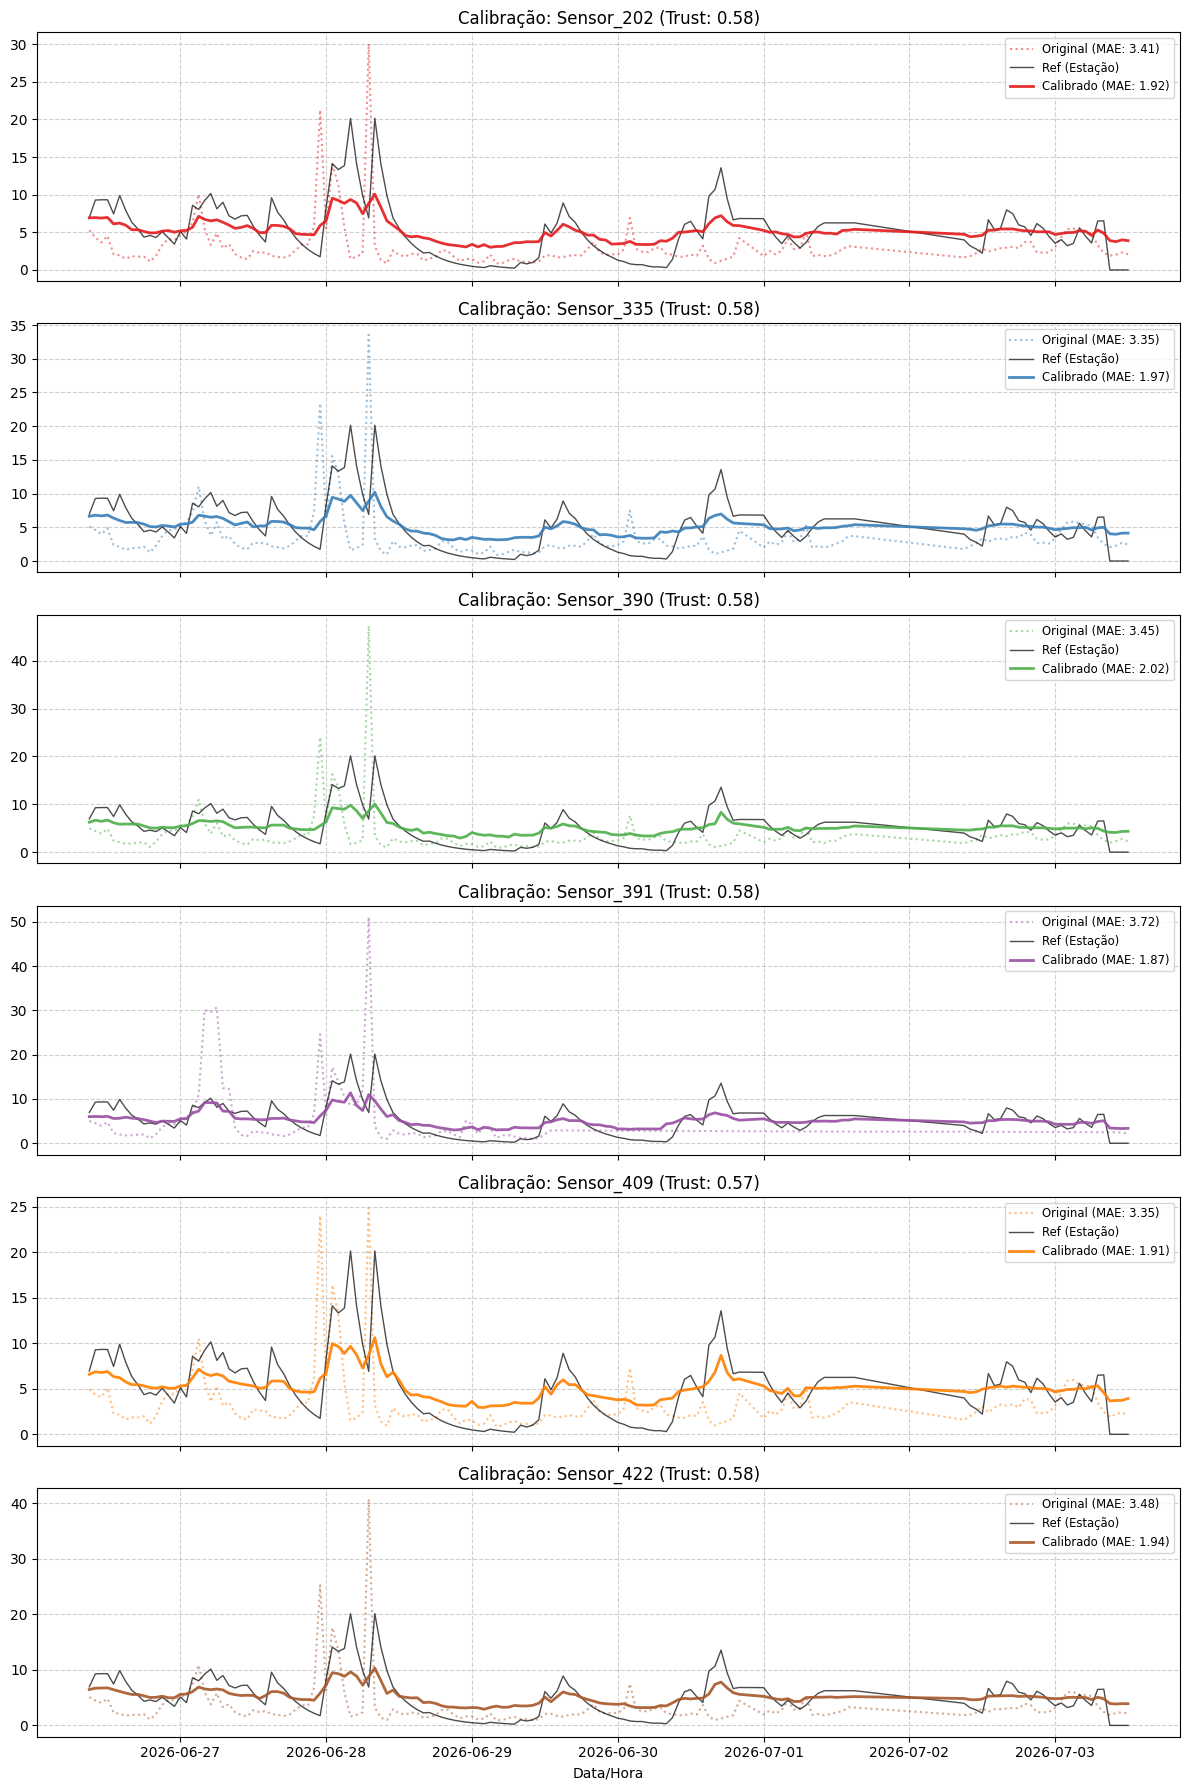

In [8]:
# --- REPARACIÓN FINAL Y DEFINITIVA ---
# 1. Sobrescribimos la columna 'Date' errónea con las fechas reales de df
df_calibrado['Date'] = df['Date']

# 2. Ahora graficamos
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(12, 18), sharex=True)
colores = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

for i, sensor in enumerate(sensores_a_calibrar):
    ax = axes[i]

    # MAE usando las columnas ahora correctamente alineadas
    mae_orig = mean_absolute_error(df['Ref'], df[sensor])
    mae_cali = mean_absolute_error(df['Ref'], df_calibrado[sensor])

    # Graficar usando 'Date' sincronizada
    ax.plot(df['Date'], df[sensor], label=f'Original (MAE: {mae_orig:.2f})',
            alpha=0.5, color=colores[i], linestyle=':', linewidth=1.5)
    ax.plot(df['Date'], df['Ref'], label='Ref (Estação)',
            alpha=0.7, color='black', linestyle='-', linewidth=1)
    ax.plot(df_calibrado['Date'], df_calibrado[sensor], label=f'Calibrado (MAE: {mae_cali:.2f})',
            alpha=0.9, color=colores[i], linewidth=2)

    ax.set_title(f'Calibração: {sensor} (Trust: {puntajes_confianza[sensor]:.2f})')
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Data/Hora')
plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import mean_absolute_error

modelos_a_probar = ['gb', 'rf', 'xgb', 'lr']
resultados_comparativa = []

for m in modelos_a_probar:
    print(f"Entrenando y evaluando con: {m.upper()}...")
    calibrador_m = HybridAdaptiveSensorCalibration(
        window_size=24, error_scale=2.0, min_trust_score=0.2,
        sensor_positions=posiciones, D=5000.0, use_spatial=True
    )

    df_res, _ = calibrador_m.fit_transform(df, sensores_a_calibrar, ref='Ref', model_type=m)

    # Calcular MAE promedio
    mae_modelo = mean_absolute_error(df['Ref'], df_res.mean(axis=1))
    resultados_comparativa.append({"Modelo": m.upper(), "MAE Promedio": mae_modelo})

df_comp_final = pd.DataFrame(resultados_comparativa)
print("\n--- TABLA COMPARATIVA DE MODELOS DE ML ---")
display(df_comp_final)

Entrenando y evaluando con: GB...


/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sens

Entrenando y evaluando con: RF...


/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sens

Entrenando y evaluando con: XGB...


...

Entrenando y evaluando con: LR...


/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sens


--- TABLA COMPARATIVA DE MODELOS DE ML ---


/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))


,Modelo,MAE Promedio
0,GB,1.934637
1,RF,1.817484
2,XGB,1.647147
3,LR,2.400192


<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2451/2883436174.py:50: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('MAE ($\mu$g/m³)', fontsize=13)
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))


Calculando para o modelo: MAE Consenso com GBM...


/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sens

Calculando para o modelo: MAE Consenso com eRF...


/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sens

Calculando para o modelo: MAE Consenso com XGBoost...


/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2451/785492798.py:104: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sens

Calculando para o modelo: MAE com LR...

--- RESUMO DE PRECISÃO (MAE) POR SENSOR E MODELO ---


Modelo,Sem Calibrar,MAE Consenso com GBM,MAE Consenso com eRF,MAE Consenso com XGBoost,MAE com LR
Sensor_202,3.414938,1.922740,1.845003,1.659500,2.452269
Sensor_335,3.352355,1.967968,1.847445,1.660152,2.431924
Sensor_390,3.446025,2.021581,1.860961,1.672045,2.465540
Sensor_391,3.718105,1.874267,1.769477,1.600988,2.280684
Sensor_409,3.349877,1.908404,1.783311,1.635205,2.396707
Sensor_422,3.478826,1.943217,1.816974,1.671919,2.455012


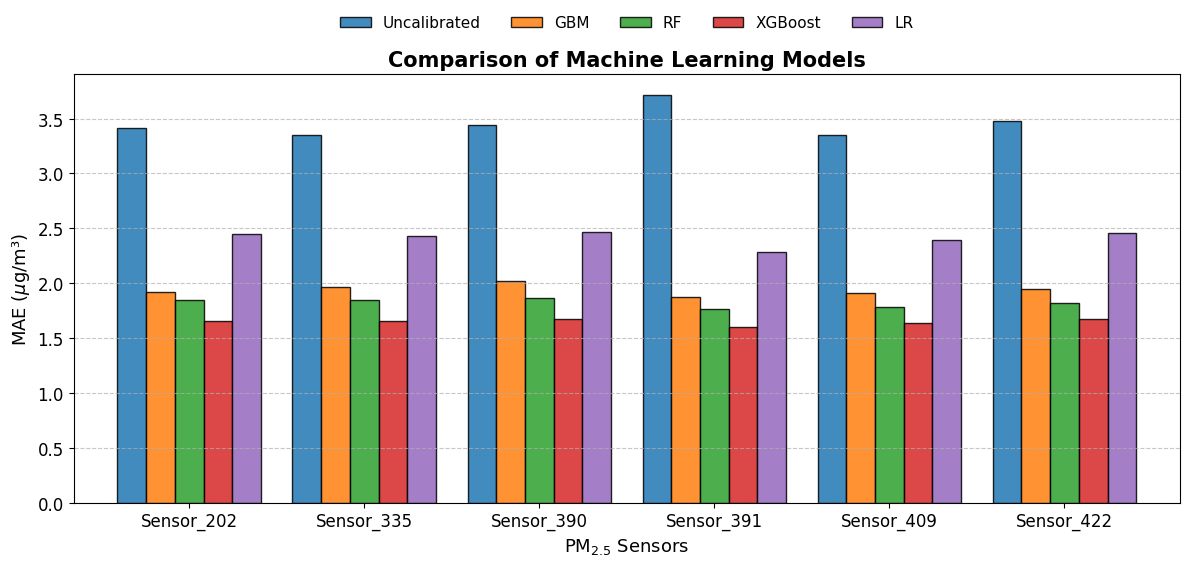

In [11]:
from sklearn.metrics import mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definimos os modelos e os nomes solicitados em português
modelos_config = [
    ('gb', 'MAE Consenso com GBM'),
    ('rf', 'MAE Consenso com eRF'),
    ('xgb', 'MAE Consenso com XGBoost'),
    ('lr', 'MAE com LR')
]

# 2. Obtemos o MAE original (Sem Calibrar) por sensor
mae_original = {sensor: mean_absolute_error(df['Ref'], df[sensor]) for sensor in sensores_a_calibrar}
datos_tabla = [{"Modelo": "Sem Calibrar", **mae_original}]

# 3. Iteramos por cada modelo para calcular o seu MAE por sensor
for m_key, m_name in modelos_config:
    print(f"Calculando para o modelo: {m_name}...")
    calibrador_m = HybridAdaptiveSensorCalibration(
        window_size=24, error_scale=2.0, min_trust_score=0.2,
        sensor_positions=posiciones, D=5000.0, use_spatial=True
    )
    df_res, _ = calibrador_m.fit_transform(df, sensores_a_calibrar, ref='Ref', model_type=m_key)

    mae_por_sensor = {sensor: mean_absolute_error(df['Ref'], df_res[sensor]) for sensor in sensores_a_calibrar}
    datos_tabla.append({"Modelo": m_name, **mae_por_sensor})

# 4. Construímos a Tabela Final (Sensores como linhas, Modelos como colunas)
df_final = pd.DataFrame(datos_tabla).set_index("Modelo").T
print("\n--- RESUMO DE PRECISÃO (MAE) POR SENSOR E MODELO ---")
display(df_final)

# Renombrar columnas para una leyenda más limpia
df_final.columns = ['Uncalibrated', 'GBM', 'RF', 'XGBoost', 'LR']

# Gráfico
ax = df_final.plot(
    kind='bar',
    figsize=(12, 5.8),      # un poco más alta
    width=0.82,
    edgecolor='black',
    alpha=0.85
)

plt.title('Comparison of Machine Learning Models',
          fontsize=15,
          fontweight='bold')

plt.ylabel('MAE ($\mu$g/m³)', fontsize=13)
plt.xlabel('PM$_{2.5}$ Sensors', fontsize=13)

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Leyenda arriba
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.17),
    ncol=5,
    fontsize=11,
    frameon=False
)

plt.tight_layout()
plt.show()